#Simple Conditional workflow

In [17]:
!pip install -q langgraph

In [18]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [19]:
class QuadState(TypedDict):
  a:int
  b:int
  c:int

  equation:str
  discriminant: float
  result :str

In [28]:
def show_equation(state:QuadState):
  a=state['a']
  b=state['b']
  c=state['c']

  return {'equation':f'{a}x2+{b}x+{c}'}


def calculate_discrminant(state:QuadState):
  a=state['a']
  b=state['b']
  c=state['c']

  dis=b*b-(4*a*c)
  return {'discriminant':dis}

def real_roots(state:QuadState):
  a=state['a']
  b=state['b']
  c=state['c']
  dis=state['discriminant']

  root1=(-b+dis**0.5)/(2*a)
  root2=(-b-dis**0.5)/(2*a)
  return {'result':f'Root1={root1} Root2={root2}'}


def repeated_roots(state:QuadState):
  a=state['a']
  b=state['b']
  c=state['c']

  root=(-b)/(2*a)
  return {'result':f"Reapeated Roots are {root}"}

def no_real_roots(state:QuadState):
  return {'result':"Equation had no real roots"}

In [29]:
def check_conditions(state:QuadState)->Literal['real_roots','repeated_roots','no_real_roots']:
  if state['discriminant']>0:
    return 'real_roots'
  elif (state['discriminant'])==0:
    return 'repeated_roots'
  else :
    return 'no_real_roots'

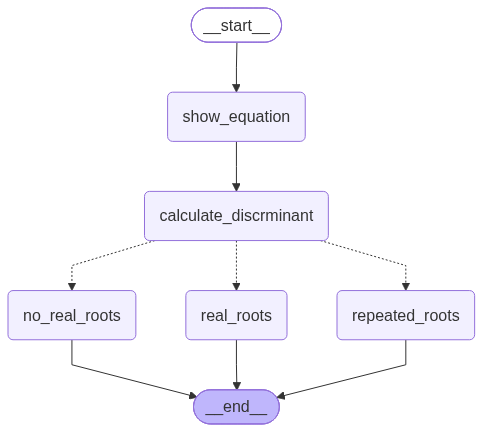

In [30]:
graph=StateGraph(QuadState)

graph.add_node('show_equation',show_equation)
graph.add_node('calculate_discrminant',calculate_discrminant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeated_roots',repeated_roots)
graph.add_node('no_real_roots',no_real_roots)


graph.add_edge(START,'show_equation')
graph.add_edge('show_equation','calculate_discrminant')
graph.add_conditional_edges('calculate_discrminant', check_conditions)
graph.add_edge('real_roots',END)
graph.add_edge('repeated_roots',END)
graph.add_edge('no_real_roots',END)

workflow=graph.compile()
workflow

In [31]:
initial_state={
    'a':2,
    'b':4,
    'c':2
}

final_state=workflow.invoke(initial_state)
final_state

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x2+4x+2',
 'discriminant': 0,
 'result': 'Reapeated Roots are -1.0'}

#Conditional Workflow With LLM

## Review Reply customer support

In [33]:
!pip install -q langchain langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.1 MB/s eta 0:00:00


In [34]:
from langchain_groq import ChatGroq

In [35]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [37]:
model=ChatGroq(
    model='openai/gpt-oss-20b',
    api_key=GROQ_API_KEY
)

In [38]:
class ReviewState(TypedDict):

  review:str
  sentiment:Literal['positive','negative']
  diagnosis:dict
  response:str

In [39]:
from pydantic import BaseModel,Field

In [40]:
class SentimentSchema(BaseModel):
  sentiment:Literal['positive','negative']=Field(description="Sentiment of the review")

In [41]:
structured_model=model.with_structured_output(SentimentSchema)

In [42]:
prompt="The phone is too good"

res1=structured_model.invoke(prompt)


In [45]:
res1.sentiment

'positive'

In [46]:
class DiagnosisSchema(BaseModel):
  issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
  tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
  urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [47]:
structured_model2=model.with_structured_output(DiagnosisSchema)

In [48]:
prompt="Diagnose this negative review :Very disappointed with my experience here. I ordered the service online and was told it would arrive within 3oxic business days. It took over two weeks, and when it finally showed up, the packaging was damaged and the item didn't work properly. I tried calling customer support three times and got stuck on hold for 20 minutes before getting disconnected. When I finally reached someone via email, they were unhelpful and refused to offer a full refund. For the price I paid, I expected much better quality and basic communication. Won't be ordering again--.return issue_type,tone,urgency"
res=structured_model2.invoke(prompt)

In [51]:
from rich import print
print(res.model_dump())

{'issue_type': 'Support', 'tone': 'frustrated', 'urgency': 'high'}

In [53]:
def find_sentiment(state:ReviewState):
  prompt = f'For the following review find out the sentiment \n {state["review"]}'

  res=structured_model.invoke(prompt).sentiment
  return {'sentiment':res}


def check_sentiment(state:ReviewState)->Literal['positive_response','run_diagnosis']:
  if state['sentiment']=='positive':
    return 'positive_response'
  else :
    return 'run_diagnosis'

def positive_response(state:ReviewState):
  prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
  Also, kindly ask the user to leave feedback on our website."""
  response=model.invoke(prompt).content
  return {'response':response}

def run_diagnosis(state:ReviewState):
  prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
  """
  response=structured_model2.invoke(prompt)
  return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState):
  diagnosis=state['diagnosis']
  prompt = f"""You are a support assistant.
  The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
  Write an empathetic, helpful resolution message.
  """

  response=model.invoke(prompt).content

  return {'response':response}




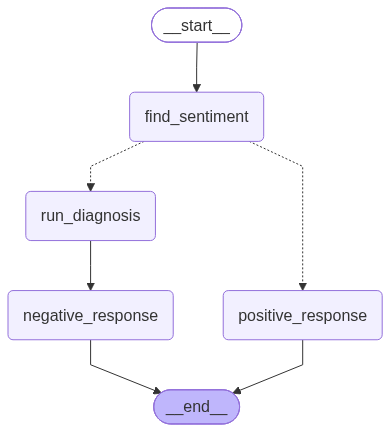

In [54]:
graph=StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow=graph.compile()
workflow

In [55]:
#bad_review
bad_review="Very disappointed with my experience here. I ordered the service online and was told it would arrive within 3oxic business days. It took over two weeks, and when it finally showed up, the packaging was damaged and the item didn't work properly. I tried calling customer support three times and got stuck on hold for 20 minutes before getting disconnected. When I finally reached someone via email, they were unhelpful and refused to offer a full refund. For the price I paid, I expected much better quality and basic communication. Won't be ordering again"

initial_state={
    'review':bad_review
}
final_state=workflow.invoke(initial_state)

In [57]:
final_state['sentiment']

'negative'

In [59]:
final_state['diagnosis']

{'issue_type': 'Support', 'tone': 'angry', 'urgency': 'high'}

In [60]:
print(final_state['response'])

Hi there,

I’m really sorry you’re dealing with this issue and for the frustration it’s caused you. I understand how stressful
this must be, especially when it’s happening right now. Let’s get it sorted out as quickly as possible.

**What’s happening?**  
From what you’ve told me, it sounds like the system is not behaving as expected and you’re unable to complete your 
task. I’m going to take a deep dive into the logs and configuration to pinpoint the root cause.

**Next steps (in the meantime):**  
1. **Can you confirm** if you’re seeing any error messages on the screen? If so, please copy/paste the exact 
wording or take a screenshot and send it to me.  
2. **Have you tried** restarting the application or your device? A quick reboot often clears transient glitches.  
3. **If you’re comfortable** sharing the last few minutes of activity (e.g., what you were doing before the error 
appeared), that would help me narrow things down faster.

**What I’ll do right now:**  
- I’ll pull up the relevant logs on my end and run a diagnostic script to check for any underlying problems.  
- I’ll also reach out to our backend team to see if there’s a known issue affecting this feature right now.  
- I’ll keep you posted every 15–20 minutes (or sooner if I find something) so you’re not left in the dark.

**Timeline:**  
I’m aiming to have a preliminary diagnosis within the next **30 minutes**. If it turns out to be a deeper issue, 
I’ll let you know the estimated time for a fix and keep you updated throughout.

Again, I’m truly sorry for the inconvenience, and I appreciate your patience as we work through this together. 
Please let me know about the error message or any other details you can share, and I’ll get right on it.

Thank you for bringing this to our attention—your experience matters a lot to us.

Warm regards,

[Your Name]  
Support Team  
[Company]

In [61]:
bad_review="Do not stay here! The photos online are highly misleading. The room smelled like smoke, the carpet was stained, and the air conditioning barely worked. To make matters worse, the walls are paper-thin, so I could hear everything from the hallway and neighboring rooms all night. When I complained to the front desk, they just said they were fully booked and couldn't move me. Safe to say I didn't get any sleep. Avoid this place"
initial_state={
    'review':bad_review
}
final_state=workflow.invoke(initial_state)

In [63]:
final_state['diagnosis']

{'issue_type': 'UX', 'tone': 'angry', 'urgency': 'high'}

In [65]:
print(final_state['response'])

Hi there,

I’m really sorry you’re having a frustrating experience with our interface. I understand how annoying it can be 
when things don’t work the way they should—especially when you’re trying to get something done quickly. I want to 
help you get back on track as fast as possible.

### Quick Fixes to Try Right Now
1. **Clear your browser cache**  
   - Chrome: `Settings > Privacy & security > Clear browsing data`  
   - Firefox: `Options > Privacy & Security > Cookies and Site Data > Clear Data`  
2. **Disable any browser extensions** that might interfere with the page (try opening in incognito/private mode 
first).  
3. **Refresh the page** and log in again—sometimes a fresh session resolves UI glitches.

If the problem still persists after these steps, here’s what we can do next:

1. **Send me a screenshot or a short screen recording** of the exact issue (e.g., a broken button, missing menu).  
2. Let me know the **browser and device** you’re using (Chrome 120 on Windows 11, Safari 17 on iPhone 15, etc.).  
3. Tell me the **exact action** you were trying to perform when the issue appeared (e.g., “I clicked ‘Submit’ and 
the page froze”).

Once I have that information, I’ll be able to replicate the problem on our end and work with our engineering team 
to resolve it. I’ll also keep you in the loop with any updates—no more surprises.

### What You Can Do While We Investigate
- If you need to complete a task urgently, you can try **using a different browser** or a **mobile device** to see 
if the issue is specific to the current setup.
- If it’s a data entry or a form, you can **copy your information** into a simple text file and paste it back in 
later—this way you won’t lose anything if the page reloads.

I truly appreciate your patience and cooperation. Your experience matters to us, and we’re committed to fixing this
quickly. Please send the requested details at your earliest convenience, and I’ll prioritize this ticket as 
high‑urgency.

Thank you for bringing this to our attention. We’ll get it sorted out together.

Warm regards,  
[Your Name]  
Customer Support Team  
---

In [67]:
good_review="""Absolutely phenomenal experience! The atmosphere was warm and inviting, and the staff made us feel like family from the moment we walked in. Every dish we ordered was beautifully presented and packed with flavor—the steak was cooked to absolute perfection. Our server was incredibly attentive without being intrusive. It’s rare to find a place where the food, service, and ambiance are all top-notch. Highly recommend!"""
initial_state={
    'review':good_review
}

final_state=workflow.invoke(initial_state)
final_state

{'review': 'Absolutely phenomenal experience! The atmosphere was warm and inviting, and the staff made us feel like family from the moment we walked in. Every dish we ordered was beautifully presented and packed with flavor—the steak was cooked to absolute perfection. Our server was incredibly attentive without being intrusive. It’s rare to find a place where the food, service, and ambiance are all top-notch. Highly recommend!',
 'sentiment': 'positive',
 'response': '**Dear Guest,**\n\nThank you so much for taking the time to share such a glowing review! We’re thrilled to hear that you felt at home, enjoyed every bite, and appreciated the care our team put into every detail. It’s always our goal to create an experience where the food, service, and atmosphere feel like a seamless family gathering—and your words confirm we’re on the right track.\n\nYour feedback truly brightens our day, and we would be honored if you could share your experience on our website as well. It helps future di

In [69]:
print(final_state['response'])

**Dear Guest,**

Thank you so much for taking the time to share such a glowing review! We’re thrilled to hear that you felt at home,
enjoyed every bite, and appreciated the care our team put into every detail. It’s always our goal to create an 
experience where the food, service, and atmosphere feel like a seamless family gathering—and your words confirm 
we’re on the right track.

Your feedback truly brightens our day, and we would be honored if you could share your experience on our website as
well. It helps future diners find their way to us and lets us keep improving. Simply click the link below and 
follow the quick steps to leave a review:

[Leave a Review on Our Website](#)

Thank you again for your kind recommendation. We look forward to welcoming you back soon for another unforgettable 
meal.

Warmest regards,

*The [Restaurant Name] Team*